In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display
import pandas as pd

EXPERIMENTS_DIR = Path("experiments")

FNAME_RE = re.compile(
    r"-dim(?P<dim>\d+)"
    r"_k(?P<k_points>\d+)"
    r"_hashes(?P<hashes>\d+)"
    r"_nonce(?P<nonces>\d+)$"
)

def parse_filename(stem: str) -> dict:
    m = FNAME_RE.search(stem)
    if not m:
        raise ValueError(f"Cannot parse filename: {stem!r}")
    d = m.groupdict()
    d["dim"]      = int(d["dim"])
    d["k_points"] = int(d["k_points"])
    d["hashes"]   = int(d["hashes"])
    d["nonces"]   = int(d["nonces"])
    return d

def url_to_hardware(url: str) -> str:
    """Infer hardware from server URL.
    0.0.0.0 → RTX 4000, any other host → A100.
    """
    host = url.split("://")[-1].split(":")[0]
    return "RTX 4000" if host == "0.0.0.0" else "A100"

def build_meta(stem: str, config: dict) -> dict:
    """Merge filename-parsed dims with config-sourced model/hardware info."""
    meta = parse_filename(stem)
    meta["primary_model"]      = config.get("primary_model", "unknown")
    meta["validation_model"]   = config.get("validation_model", "unknown")
    meta["primary_hardware"]   = url_to_hardware(config.get("primary_url", ""))
    meta["validation_hardware"]= url_to_hardware(config.get("validation_url", ""))
    return meta

def setup_title(meta: dict) -> str:
    p_label = f"{meta['primary_model']} ({meta['primary_hardware']})"
    v_label = f"{meta['validation_model']} ({meta['validation_hardware']})"
    return (
        f"P: {p_label}\n"
        f"V: {v_label}\n"
        f"dim={meta['dim']} · k={meta['k_points']} · "
        f"{meta['hashes']} hashes · {meta['nonces']} nonces"
    )

experiments = []
for path in sorted(EXPERIMENTS_DIR.glob("*.json")):
    try:
        with open(path) as f:
            data = json.load(f)
        meta = build_meta(path.stem, data.get("config", {}))
    except ValueError as e:
        print(f"Skipping {path.name}: {e}")
        continue
    experiments.append({"meta": meta, "data": data, "path": path})
    print(f"Loaded  {path.name}  ({len(data['records'])} records)")
# experiments = experiments[:-1]
print(f"\nTotal experiments: {len(experiments)}")

Loaded  Qwen2.5-7B-A100-dim256_k16_hashes4_nonce256.json  (1024 records)
Loaded  Qwen2.5-7B-A100-dim256_k8_hashes4_nonce256.json  (1024 records)
Loaded  Qwen2.5-7B-A100-dim3_k16_hashes4_nonce256.json  (1024 records)
Loaded  Qwen2.5-7B-A100-dim3_k8_hashes4_nonce256.json  (1024 records)
Loaded  Qwen2.5-7B-A100-rtx-dim256_k16_hashes4_nonce256.json  (1024 records)
Loaded  Qwen2.5-7B-diff-A100-dim256_k16_hashes4_nonce256.json  (1024 records)

Total experiments: 6


In [2]:
for exp in experiments:
    meta    = exp["meta"]
    records = exp["data"]["records"]
    title   = setup_title(meta)

    total       = len(records)
    mismatches  = [
        r for r in records
        if not r.get("primary_consistent", True)
        or not r.get("validation_consistent", True)
        or not r.get("match", True)
    ]
    n_mismatch  = len(mismatches)
    match_rate  = (total - n_mismatch) / total if total else 0.0

    n_cross    = sum(1 for r in records if not r.get("match", True))
    n_p_incons = sum(1 for r in records if not r.get("primary_consistent", True))
    n_v_incons = sum(1 for r in records if not r.get("validation_consistent", True))

    per_hash: dict = defaultdict(lambda: {"total": 0, "mismatch": 0})
    for r in records:
        h = r["block_hash"][:12]
        per_hash[h]["total"] += 1
        if r in mismatches:
            per_hash[h]["mismatch"] += 1

    print(f"\\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Total records       : {total}")
    print(f"  Total mismatches    : {n_mismatch}  ({(1-match_rate)*100:.2f} %)")
    print(f"  Overall match rate  : {match_rate*100:.2f} %")
    print(f"")
    print(f"  Breakdown of mismatches:")
    print(f"    cross-server disagree  : {n_cross}")
    print(f"    primary inconsistent   : {n_p_incons}")
    print(f"    validation inconsistent: {n_v_incons}")
    print(f"")
    print(f"  Per hash:")
    print(f"    {'hash':14s}  {'total':>7s}  {'mismatch':>8s}  {'rate':>6s}")
    print(f"    {'-'*40}")
    for h, s in per_hash.items():
        r = s['mismatch'] / s['total'] if s['total'] else 0
        print(f"    {h}  {s['total']:>7d}  {s['mismatch']:>8d}  {r*100:>5.1f} %")

\n============================================================
  P: RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16 (A100)
V: RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16 (A100)
dim=256 · k=16 · 4 hashes · 256 nonces
  Total records       : 1024
  Total mismatches    : 53  (5.18 %)
  Overall match rate  : 94.82 %

  Breakdown of mismatches:
    cross-server disagree  : 16
    primary inconsistent   : 48
    validation inconsistent: 48

  Per hash:
    hash              total  mismatch    rate
    ----------------------------------------
    50a6c8d1e0cf      256        14    5.5 %
    bf7e205368f0      256        12    4.7 %
    978c8fcd7a7a      256        16    6.2 %
    bcbd3d590c54      256        11    4.3 %
\n============================================================
  P: RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16 (A100)
V: RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16 (A100)
dim=256 · k=8 · 4 hashes · 256 nonces
  Total records       : 1024
  Total mismatches    : 30  (2.93 %)
 

## 2 · k-point frequency per hash

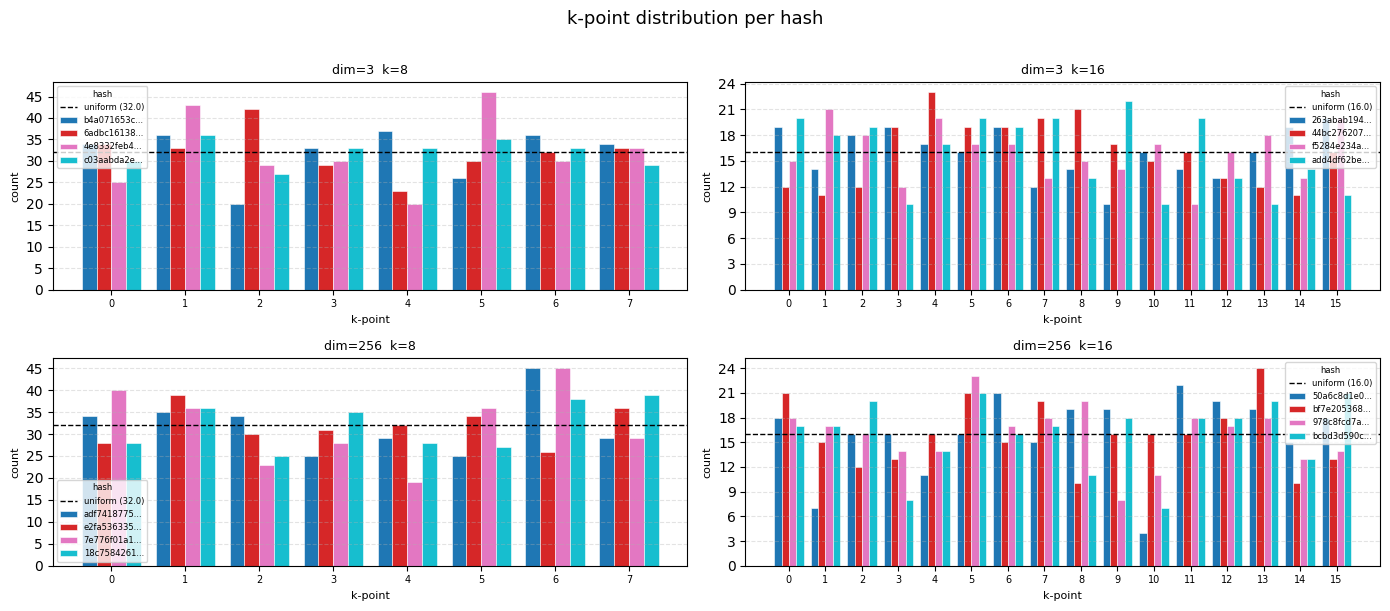

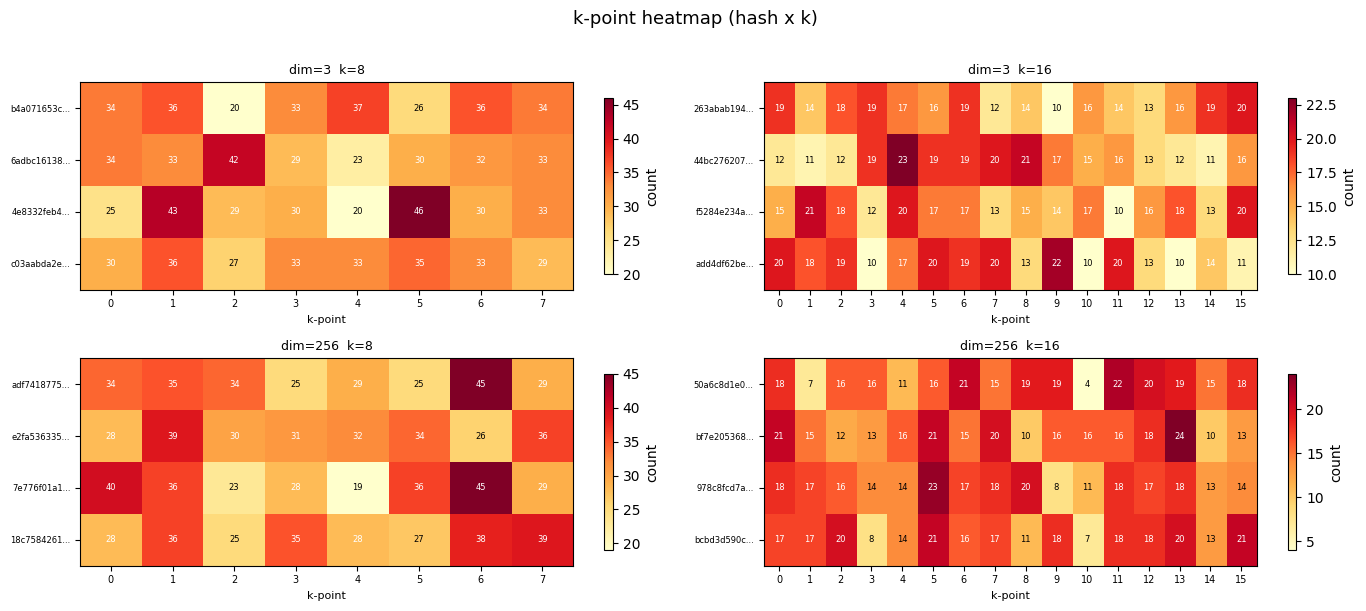

In [ ]:
all_dims = sorted({exp["meta"]["dim"]      for exp in experiments})
all_ks   = sorted({exp["meta"]["k_points"] for exp in experiments})

n_rows = len(all_dims)
n_cols = len(all_ks)

dim_row = {d: i for i, d in enumerate(all_dims)}
k_col   = {k: i for i, k in enumerate(all_ks)}

def make_counts(records, hashes, k_max):
    counts  = np.zeros((len(hashes), k_max), dtype=int)
    by_hash = defaultdict(list)
    for r in records:
        by_hash[r["block_hash"]].append(r)
    for hi, h in enumerate(hashes):
        for r in by_hash[h]:
            kv = r.get("primary_sphere_k", -1)
            if 0 <= kv < k_max:
                counts[hi, kv] += 1
    return counts

exp_data = []
for exp in experiments:
    meta    = exp["meta"]
    records = exp["data"]["records"]
    by_hash = defaultdict(list)
    for r in records:
        by_hash[r["block_hash"]].append(r)
    hashes       = list(by_hash.keys())
    short_labels = [h[:10] + "..." for h in hashes]
    k_max        = meta["k_points"]
    counts       = make_counts(records, hashes, k_max)
    exp_data.append({
        "meta": meta, "hashes": hashes,
        "short_labels": short_labels, "counts": counts,
    })

used = {(dim_row[ed["meta"]["dim"]], k_col[ed["meta"]["k_points"]]) for ed in exp_data}

fig_dist, axes_dist = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 7, n_rows * 3),
    squeeze=False,
)
fig_dist.suptitle("k-point distribution per hash", fontsize=13, y=1.01)

for ed in exp_data:
    meta         = ed["meta"]
    counts       = ed["counts"]
    short_labels = ed["short_labels"]
    k_max        = meta["k_points"]
    n_hashes     = len(ed["hashes"])
    ax           = axes_dist[dim_row[meta["dim"]], k_col[k_max]]

    x      = np.arange(k_max)
    bar_w  = 0.8 / n_hashes
    colors = plt.cm.tab10(np.linspace(0, 0.9, n_hashes))
    for hi, (label, color) in enumerate(zip(short_labels, colors)):
        offset = (hi - n_hashes / 2 + 0.5) * bar_w
        ax.bar(x + offset, counts[hi], width=bar_w, label=label,
               color=color, edgecolor="white", linewidth=0.4)
    expected = meta["nonces"] / k_max
    ax.axhline(expected, color="black", lw=1.0, ls="--",
               label=f"uniform ({expected:.1f})")
    ax.set_xticks(x)
    ax.set_xticklabels([str(kv) for kv in range(k_max)], fontsize=7)
    ax.set_xlabel("k-point", fontsize=8)
    ax.set_ylabel("count", fontsize=8)
    ax.set_title(f"dim={meta['dim']}  k={k_max}", fontsize=9)
    ax.legend(fontsize=6, title="hash", title_fontsize=6)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(axis="y", linestyle="--", alpha=0.35)

for ri in range(n_rows):
    for ci in range(n_cols):
        if (ri, ci) not in used:
            axes_dist[ri, ci].set_visible(False)

plt.tight_layout()
plt.show()

fig_heat, axes_heat = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 7, n_rows * 3),
    squeeze=False,
)
fig_heat.suptitle("k-point heatmap (hash x k)", fontsize=13, y=1.01)

for ed in exp_data:
    meta         = ed["meta"]
    counts       = ed["counts"]
    short_labels = ed["short_labels"]
    k_max        = meta["k_points"]
    n_hashes     = len(ed["hashes"])
    ax           = axes_heat[dim_row[meta["dim"]], k_col[k_max]]

    im   = ax.imshow(counts, aspect="auto", cmap="YlOrRd")
    plt.colorbar(im, ax=ax, label="count", shrink=0.85)
    ax.set_xticks(range(k_max))
    ax.set_xticklabels([str(kv) for kv in range(k_max)], fontsize=7)
    ax.set_yticks(range(n_hashes))
    ax.set_yticklabels(short_labels, fontsize=6)
    ax.set_xlabel("k-point", fontsize=8)
    ax.set_title(f"dim={meta['dim']}  k={k_max}", fontsize=9)
    vmax = counts.max() if counts.max() > 0 else 1
    for hi in range(n_hashes):
        for ki in range(k_max):
            ax.text(ki, hi, str(counts[hi, ki]),
                    ha="center", va="center", fontsize=6,
                    color="white" if counts[hi, ki] > vmax * 0.6 else "black")

for ri in range(n_rows):
    for ci in range(n_cols):
        if (ri, ci) not in used:
            axes_heat[ri, ci].set_visible(False)

plt.tight_layout()
plt.show()

## 3 · Summary table

In [ ]:
rows = []
for exp in experiments:
    meta    = exp["meta"]
    records = exp["data"]["records"]
    total      = len(records)
    mismatches = [
        r for r in records
        if not r.get("primary_consistent", True)
        or not r.get("validation_consistent", True)
        or not r.get("match", True)
    ]
    n_mismatch = len(mismatches)
    match_rate = (total - n_mismatch) / total if total else 0.0

    per_hash = defaultdict(lambda: {"total": 0, "mismatch": 0})
    for r in records:
        per_hash[r["block_hash"]]["total"] += 1
    for r in mismatches:
        per_hash[r["block_hash"]]["mismatch"] += 1
    hash_rates = [s["mismatch"] / s["total"] for s in per_hash.values() if s["total"]]
    mean_mm_per_hash = sum(hash_rates) / len(hash_rates) if hash_rates else 0.0
    rows.append({
    "primary_model":         meta["primary_model"],
    "primary_hw":            meta["primary_hardware"],
    "validation_model":      meta["validation_model"],
    "validation_hw":         meta["validation_hardware"],
    "dim":                   meta["dim"],
    "k":                     meta["k_points"],
    "hashes":                meta["hashes"],
    "nonces":                meta["nonces"],
    "total_records":         total,
    "total_mismatches":      n_mismatch,
    "match_rate_%":          round(match_rate * 100, 2),
    "mean_mismatch/hash_%":  round(mean_mm_per_hash * 100, 2),
    })
df = pd.DataFrame(rows)
df.sort_values(by=["dim", "k"])

,primary_model,primary_hw,validation_model,validation_hw,dim,k,hashes,nonces,total_records,total_mismatches,match_rate_%,mean_mismatch/hash_%
3,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,3,8,4,256,1024,49,95.21,4.79
2,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,3,16,4,256,1024,82,91.99,8.01
1,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,256,8,4,256,1024,30,97.07,2.93
0,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,256,16,4,256,1024,53,94.82,5.18
4,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,RTX 4000,256,16,4,256,1024,61,94.04,5.96
5,RedHatAI/Qwen2.5-7B-Instruct-quantized.w8a16,A100,Qwen/Qwen2.5-7B-Instruct-AWQ,A100,256,16,4,256,1024,348,66.02,33.98
